170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


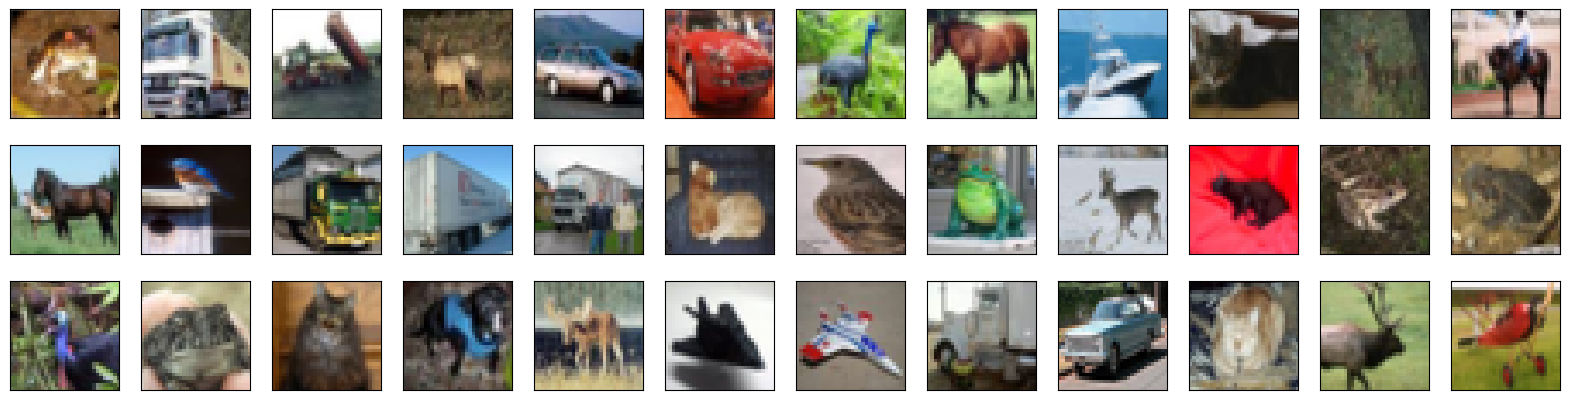

In [ ]:
from keras.datasets.cifar10 import load_data
import matplotlib.pyplot as plt
(train_x,train_y),(test_x,test_y) = load_data()
fig = plt.figure(figsize=(20,5))
for i in range(36):
    ax = fig.add_subplot(3, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(train_x[i])

In [ ]:
print(train_x.shape)

(50000, 32, 32, 3)


In [ ]:
train_x.dtype

dtype('uint8')

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Conv2D,Conv2DTranspose,Flatten,Dropout,Reshape
from keras.layers import BatchNormalization
from keras.layers import LeakyReLU
from keras.optimizers import Adam
import numpy as np

def define_discriminator(in_shape=(32,32,3)):
  # define model
  model = Sequential()
  model.add(Conv2D(64, kernel_size=(3,3), padding='same', input_shape=in_shape))
  model.add(LeakyReLU(0.2))
  # downsample
  model.add(Conv2D(128, kernel_size=(3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(0.2))
  # downsample
  model.add(Conv2D(128, kernel_size=(3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(0.2))
  # downsample
  model.add(Conv2D(256, kernel_size=(3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(0.2))
  model.add(Flatten())
  model.add(Dropout(0.4))
  model.add(Dense(1,activation="sigmoid"))
  # compile model
  opt = Adam(learning_rate=0.0002, beta_1=0.5)
  model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
  return model


In [ ]:
model = define_discriminator()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 522,497 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def load_real_samples():
  (train_x,_),(_,_) = load_data()
  images = train_x.astype('float32')
  # scale from [0,255] to [-1,1] ## 0 pixel = -1 255 = 1
  images = (images - 127.5) / 127.5
  return images

In [ ]:
# 50000 X 32 x32 x 3
# n_sample = 64
# X = 64 X 32 X 32 X 3
# y = [[1],
       [1],
       [1],
       ........ 64

In [ ]:
# generate n real samples with class label 1
def generate_real_samples(dataset,n_samples):
  #choose random instances
  ix= np.random.randint(0,dataset.shape[0],n_samples)
  # list of selected images in x
  x=dataset[ix]
  y = np.ones((n_samples,1))
  return x,y

In [ ]:
np.random.rand(4)

array([0.94277845, 0.91275852, 0.74915941, 0.95906049])

In [ ]:
32*32*3*64
# [0,1] --> [-1,1]
# 64*32*32*3

196608

In [ ]:
# generate n fake sampes with class label 0
def generate_fake_samples(n_samples): # 64
  #uniform random numbers [0,1]
  x = np.random.rand(32*32*3*n_samples) ## 98304 numbers between 0 and 1
  #making in range of -1 to 1
  x = -1 + x*2 ## 1 --> 1 and 0 --> -1
  #reshape in batch of color images
  x = x.reshape(n_samples,32,32,3)
  # genrating fake labels(0)
  y = np.zeros((n_samples,1))
  return x,y

In [ ]:
samples_real,labels_real = generate_real_samples(train_x,64)

In [ ]:
print(len(samples_real))
print(len(labels_real))

64
64


In [ ]:
print(samples_real.shape)
print(labels_real.shape)

(64, 32, 32, 3)
(64, 1)


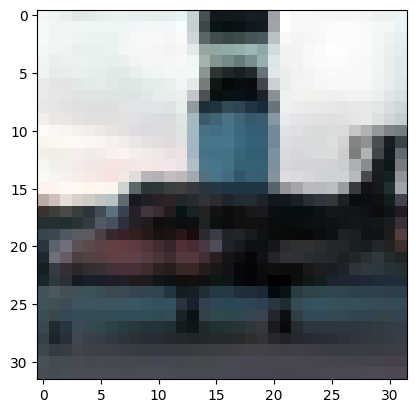

In [ ]:
plt.imshow(samples_real[23])

In [ ]:
xfake,yfake= generate_fake_samples(64)

In [ ]:
print(xfake.shape)
print(yfake.shape)

(64, 32, 32, 3)
(64, 1)


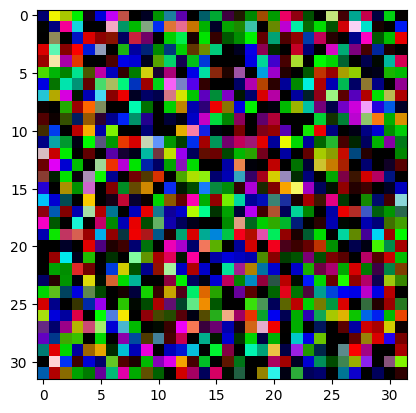

In [ ]:
plt.imshow(xfake[23])

In [ ]:
model.fit(x_train,y_train)

In [ ]:
def train_discriminator(model,datset,n_iter=75,n_batch=128):
  half_batch = int(n_batch/2) # 64
  # manually enumerate epochs
  for i in range(n_iter):
    # randomly selected real samples
    x_real,y_real = generate_real_samples(datset,half_batch) # 50000 datapoints,64
    # training on those real samples
    _,real_acc = model.train_on_batch(x_real,y_real)
    # randomly selected fake samples
    x_fake,y_fake = generate_fake_samples(half_batch)
    #training on those samples
    _,fake_acc = model.train_on_batch(x_fake,y_fake)
    print("real data accuracy --> {} | Fake data accuracy --> {}".format(real_acc,fake_acc))


In [ ]:
## Example training
model = define_discriminator()
dataset = load_real_samples()
train_discriminator(model,dataset)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


real data accuracy --> 0.59375 | Fake data accuracy --> 0.3046875
real data accuracy --> 0.5364583134651184 | Fake data accuracy --> 0.40234375
real data accuracy --> 0.5218750238418579 | Fake data accuracy --> 0.4401041567325592
real data accuracy --> 0.5178571343421936 | Fake data accuracy --> 0.494140625
real data accuracy --> 0.5503472089767456 | Fake data accuracy --> 0.574999988079071
real data accuracy --> 0.6136363744735718 | Fake data accuracy --> 0.640625
real data accuracy --> 0.667067289352417 | Fake data accuracy --> 0.6908482313156128
real data accuracy --> 0.7083333134651184 | Fake data accuracy --> 0.7265625
real data accuracy --> 0.7398896813392639 | Fake data accuracy --> 0.7543402910232544
real data accuracy --> 0.7639802694320679 | Fake data accuracy --> 0.7757812738418579
real data accuracy --> 0.7864583134651184 | Fake data accuracy --> 0.7961647510528564
real data accuracy --> 0.804347813129425 | Fake data accuracy --> 0.8125
real data accuracy --> 0.818750023841

In [ ]:

def define_generator(latent_dim):
  model = Sequential()
  n_nodes = 256*4*4 # 4096
  model.add(Dense(n_nodes,input_dim=latent_dim))
  model.add(LeakyReLU(alpha=0.2))
  model.add(Reshape((4,4,256)))
  # upsample to 8x8
  model.add(Conv2DTranspose(128, kernel_size=(4,4), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))
  # upsample to 16x16
  model.add(Conv2DTranspose(128, kernel_size=(4,4), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))
  # upsample of 32x32
  model.add(Conv2DTranspose(128, kernel_size=(4,4), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))
  #output layer
  model.add(Conv2D(3,(3,3),activation='tanh',padding='same')) # 32 X 32 X 3
  return model



In [ ]:
latent_dim = 100
model = define_generator(latent_dim)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4096)           │       413,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 3)      │         3,459 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466,115 (5.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def generate_latent_points(latent_dim,n_samples):
   #generate points in the latent space
   x_input = np.random.randn(latent_dim*n_samples) # 100 X 64 = 6400
   # reshape into batch of inputs
   x_input = x_input.reshape(n_samples,latent_dim) # 64 X 100
   return x_input

In [ ]:
# generator to generate n fake samples, with class labels
def generate_fake_samples(g_model,latent_dim,n_samples):
  #generate points in latent space
  x_input = generate_latent_points(latent_dim,n_samples)
  # generate the output by prediction from generator
  X = g_model.predict(x_input)
  # create fake class label 0
  y = np.zeros((n_samples,1))
  return X,y

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


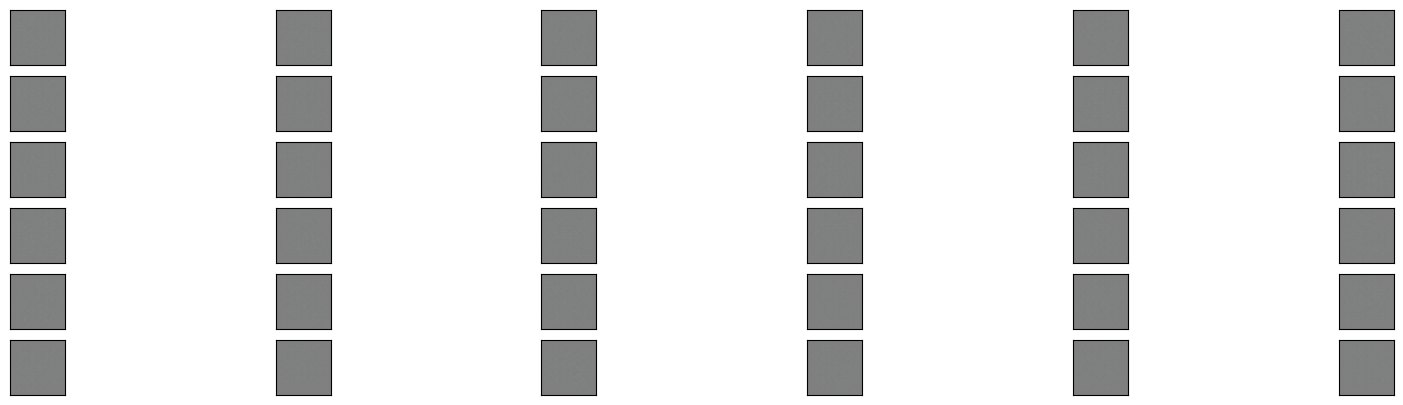

In [ ]:
latent_dim = 100

model = define_generator(latent_dim)
n_samples=36
X,_ = generate_fake_samples(model,latent_dim,n_samples)
# scale pixel values from [-1,1] to [0,1]
X = (X+1)/2.0
# plot the generated samples
fig = plt.figure(figsize =(20,5))
for i in range(n_samples):
  ax = fig.add_subplot(6,6,i + 1, xticks=[], yticks=[])
  ax.imshow(X[i])



In [ ]:
def define_gan(g_model,d_model):
  d_model.trabainle = False
  model = Sequential()
  model.add(g_model)
  model.add(d_model)
  opt = Adam(learning_rate=0.0002,beta_1 = 0.5)
  model.compile(loss="binary_crossentropy",optimizer = opt)
  return model

In [ ]:
laten_dim = 100
d_model = define_discriminator()
g_model = define_generator(latent_dim)
gan_model = define_gan(g_model,d_model)
gan_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 32, 32, 3)      │     1,466,115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 1)              │       522,497 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,988,612 (7.59 MB)

 Trainable params: 1,988,612 (7.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
train_x.shape

In [ ]:
# 1 epoch --> 1 complete dataset training --> 50000
50000/128

390.625

In [ ]:
def train(g_model,d_model,gan_model,dataset,latent_dim=100,n_epochs=200,n_batch=128):
  batch_per_epo = int(dataset.shape[0]/n_batch) # no of batches to complete full dataset = 390
  half_batch=int(n_batch/2) # 64
  for i in range(n_epochs):
    for j in range(batch_per_epo): # j = 0 in first iteration
      x_real,y_real = generate_real_samples(dataset,half_batch) # x real- 64 , y-real(1) -- 64
      d_loss_real,_ = d_model.train_on_batch(x_real,y_real)
      x_fake,y_fake = generate_fake_samples(g_model,latent_dim,half_batch) # x fake - 64, y_fake(0) - 64
      d_loss_fake,_ = d_model.train_on_batch(x_fake,y_fake)
      x_gan = generate_latent_points(latent_dim,n_batch) ## array of noise 128X100
      y_gan = np.ones((n_batch,1))
      g_loss = gan_model.train_on_batch(x_gan,y_gan)
      print(f"epoch {i} batch {j} of 390, d_loss real {d_loss_real}, d_loss_fake {d_loss_fake},gan loss {g_loss}")
  return g_model


In [ ]:
# def save_plot(examples,epoch,n=7)
x = train(g_model,d_model,gan_model,dataset,latent_dim,n_epochs=1,n_batch=128)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
epoch 0 batch 0 of 390, d_loss real 0.6923949718475342, d_loss_fake 0.694455087184906,gan loss 0.6905866861343384
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
epoch 0 batch 1 of 390, d_loss real 0.6612723469734192, d_loss_fake 0.6724816560745239,gan loss 0.6861821413040161
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
epoch 0 batch 2 of 390, d_loss real 0.6364953517913818, d_loss_fake 0.6521125435829163,gan loss 0.677741289138794
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
epoch 0 batch 3 of 390, d_loss real 0.6053134202957153, d_loss_fake 0.6288721561431885,gan loss 0.6621122360229492
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
epoch 0 batch 4 of 390, d_loss real 0.5794047713279724, d_loss_fake 0.6141184568405151,gan loss 0.6387094259262085
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
epoch 0 batch 5 of 390, d_loss real 0.5665460824966431, d_loss_fake 0.614506721496582,gan loss 0.6119928956031799
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
epoch 0 batch 6 of 390, d_loss real 0.57

In [ ]:
type(x)

In [ ]:
latent_dim = 100


n_samples=36
X,_ = generate_fake_samples(x,latent_dim,n_samples)
# scale pixel values from [-1,1] to [0,1]
X = (X+1)/2.0
# plot the generated samples
fig = plt.figure(figsize =(20,5))
for i in range(n_samples):
  ax = fig.add_subplot(6,6,i + 1, xticks=[], yticks=[])
  ax.imshow(X[i])

In [ ]:
myinp = generate_latent_points(100,16)

In [ ]:
myinp.shape